# 01 — Data Collection & Exploration
This notebook will help in:
1. **Data-Collection** by launching the imu_collector.py code, an alternate way to if desktop application based approach is not used.
2. **Loads** the collected data in csv-format with different g-values ($\pm 2$, $\pm 4$, $\pm 8$, $\pm 16$) and applies z-score normalization to check whether the range of data remains consistent and g-agnostic. 
3. **Explores** raw signals for each activity
4. **Applies Z-score normalisation** to make data g-value agnostic


In [1]:
import PyQt5
print("PyQt5 found:", PyQt5.__file__)

PyQt5 found: D:\research_project\HAR_ESP32_venv\lib\site-packages\PyQt5\__init__.py


## Step 1 — Launch the IMU Collector App (optional, if not already collected using desktop application)
> Run this cell to open the desktop GUI. Collect your data, then come back here.

In [2]:
import subprocess
import sys
import os
from pathlib import Path

# Path to imu_collector.py — one level above the notebooks/ folder
app_script = Path("..") /"studio"/ "imu_collector.py"

# Path to the pre-built standalone executable (if using PyInstaller)
if sys.platform == "win64":
    app_exe = Path("..") / "dist" / "HAR Data Acquisition.exe"
elif sys.platform == "darwin":
    app_exe = Path("..") / "dist" / "HAR Data Acquisition.app" / "Contents" / "MacOS" / "HAR Data Acquisition"
else:  # Linux
    app_exe = Path("..") / "dist" / "HAR Data Acquisition"

# Launch the executable if it exists, otherwise fall back to running the .py script
if app_exe.exists():
    print(f"Launching standalone app: {app_exe}")
    subprocess.Popen([str(app_exe)])
elif app_script.exists():
    print(f"Launching Python script: {app_script}")
    subprocess.Popen([sys.executable, str(app_script)])
else:
    print("ERROR: Neither the .exe nor imu_collector.py was found.")
    print(f"Expected script at: {app_script.resolve()}")

print("\nCollect your data in the app, then run the cells below to analyse it.")

Launching Python script: ..\studio\imu_collector.py

Collect your data in the app, then run the cells below to analyse it.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

data_dir = Path("..") / "dataset" / "data_M5stickC"

dfs = []
for f in sorted(data_dir.glob("*.csv")):
    df = pd.read_csv(f)
    
    # Skip files that don't have the g_scale column
    if "g_scale" not in df.columns:
        print(f"skipping this csv from analysis: {f.name} — no g_scale column (old file)")
        continue
    
    df["source_file"] = f.name
    dfs.append(df)
    print(f"Loading this csv for analysis: {f.name} → {len(df)} samples | g_scales: {df['g_scale'].unique()}")

df_all = pd.concat(dfs, ignore_index=True)
print(f"\nTotal samples: {len(df_all)}")
print("All g_scales found:", sorted(df_all["g_scale"].unique()))
print("Activities:", df_all["activity"].unique())
df_all.head()

skipping this csv from analysis: m5stick_20260406_104709.csv — no g_scale column (old file)
skipping this csv from analysis: m5stick_20260406_124221.csv — no g_scale column (old file)
skipping this csv from analysis: m5stick_20260406_124443.csv — no g_scale column (old file)
skipping this csv from analysis: m5stick_20260410_154653.csv — no g_scale column (old file)
skipping this csv from analysis: m5stick_20260413_133051.csv — no g_scale column (old file)
Loading this csv for analysis: m5stick_2_4_g_500dps.csv → 1141 samples | g_scales: ['AFS_2G' 'AFS_4G' 'AFS_8G']
Loading this csv for analysis: m5stick_8_16_g_500dps.csv → 905 samples | g_scales: ['AFS_8G' 'AFS_16G']
skipping this csv from analysis: m5stick_data_20250709_171243.csv — no g_scale column (old file)

Total samples: 2046
All g_scales found: ['AFS_16G', 'AFS_2G', 'AFS_4G', 'AFS_8G']
Activities: ['Eating' 'Walking']


,timestamp,activity,g_scale,sample_id,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,acc_x_raw,acc_y_raw,acc_z_raw,gyro_x_raw,gyro_y_raw,gyro_z_raw,gravity_mag,received_at,source_file
0,41760,Eating,AFS_2G,443,0.795147,3.374583,10.03513,-0.058856,-0.307861,0.076166,0.081055,0.343994,1.022949,-3.372192,-17.639160,4.364014,10.61715,2026-04-13T19:06:49.181174,m5stick_2_4_g_500dps.csv
1,41811,Eating,AFS_2G,444,0.589175,3.362607,9.79084,-0.067911,-0.261522,0.062584,0.060059,0.342773,0.998047,-3.890991,-14.984130,3.585815,10.36893,2026-04-13T19:06:49.245095,m5stick_2_4_g_500dps.csv
2,41862,Eating,AFS_2G,445,1.219065,3.324287,10.54288,-0.144343,-0.200802,0.131560,0.124268,0.338867,1.074707,-8.270264,-11.505130,7.537842,11.12157,2026-04-13T19:06:49.245095,m5stick_2_4_g_500dps.csv
3,41913,Eating,AFS_2G,446,1.175955,3.523074,10.28421,-0.224504,-0.160322,0.286822,0.119873,0.359131,1.048340,-12.863160,-9.185791,16.433720,10.93435,2026-04-13T19:06:49.293632,m5stick_2_4_g_500dps.csv
4,41964,Eating,AFS_2G,447,1.326841,3.654800,10.34649,-0.321976,0.058057,0.486027,0.135254,0.372559,1.054688,-18.447880,3.326416,27.847290,11.05296,2026-04-13T19:06:49.358027,m5stick_2_4_g_500dps.csv


## Step 2 — Visualize Raw Signals

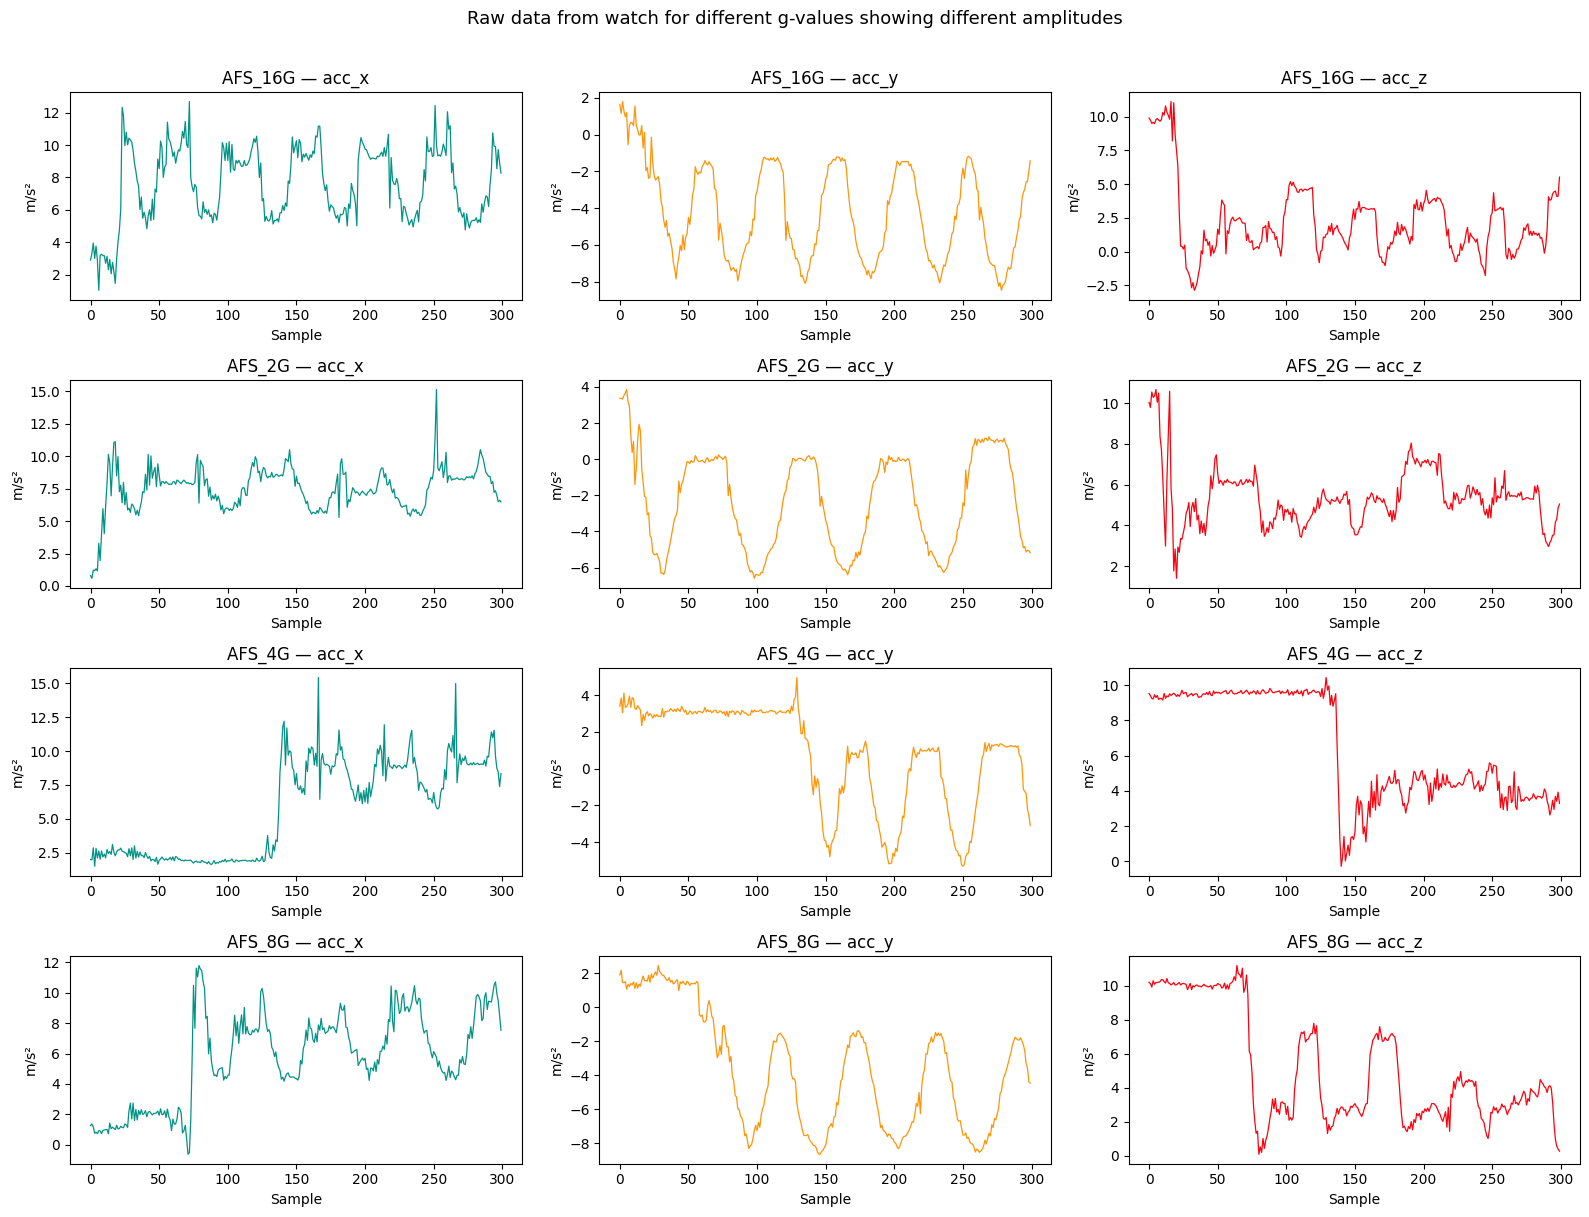

In [13]:
g_scales = sorted(df_all["g_scale"].unique())
channels = ["acc_x", "acc_y", "acc_z"]
colors   = {"acc_x": "#029386", "acc_y": "#ff9408", "acc_z": "#ff000d"}

fig, axes = plt.subplots(len(g_scales), 3, figsize=(16, 3 * len(g_scales)), sharey=False)

for row, gs in enumerate(g_scales):
    subset = df_all[df_all["g_scale"] == gs].head(300).reset_index(drop=True)
    for col, ch in enumerate(channels):
        axes[row][col].plot(subset[ch].values, color=colors[ch], linewidth=0.9)
        axes[row][col].set_title(f"{gs} — {ch}")
        axes[row][col].set_xlabel("Sample")
        axes[row][col].set_ylabel("m/s²")

plt.suptitle("Raw data from watch for different g-values showing different amplitudes", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Step 3 — Z Score Normalization

Represented as $ z = \frac{x - \mu}{\sigma} $

After this step, data collected at different **g-values** ($\pm 2$, $\pm 4$, $\pm 8$, $\pm 16$) will be directly comparable.

In [15]:
import pandas as pd

sensor_cols = [c for c in ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]
               if c in df_all.columns]

g_scales = sorted(df_all["g_scale"].unique())

# Apply Z-score per g_scale group
df_norm = df_all.copy()
for gs in g_scales:
    mask = df_norm["g_scale"] == gs
    for col in sensor_cols:
        mu    = df_all.loc[mask, col].mean()
        sigma = df_all.loc[mask, col].std()
        df_norm.loc[mask, col] = (df_all.loc[mask, col] - mu) / sigma

print("=== Raw stats (all sensor channels) ===")
print(df_all.groupby("g_scale")[sensor_cols].mean().round(3))

print("\n=== Post Z-score means (should all be ≈0) ===")
print(df_norm.groupby("g_scale")[sensor_cols].mean().round(3))

print("\n=== Post Z-score std (should all be ≈1) ===")
print(df_norm.groupby("g_scale")[sensor_cols].std().round(3))

=== Raw stats (all sensor channels) ===
         acc_x  acc_y  acc_z  gyro_x  gyro_y  gyro_z
g_scale                                             
AFS_16G  7.089 -3.992  2.803   0.010  -0.166   0.018
AFS_2G   6.418 -1.678  5.946  -0.021  -0.145   0.076
AFS_4G   6.918 -0.390  5.285  -0.035  -0.141   0.066
AFS_8G   6.031 -3.963  4.565  -0.017  -0.168   0.047

=== Post Z-score means (should all be ≈0) ===
         acc_x  acc_y  acc_z  gyro_x  gyro_y  gyro_z
g_scale                                             
AFS_16G   -0.0   -0.0   -0.0    -0.0     0.0    -0.0
AFS_2G    -0.0    0.0   -0.0    -0.0    -0.0     0.0
AFS_4G    -0.0   -0.0    0.0     0.0     0.0     0.0
AFS_8G    -0.0    0.0   -0.0     0.0    -0.0    -0.0

=== Post Z-score std (should all be ≈1) ===
         acc_x  acc_y  acc_z  gyro_x  gyro_y  gyro_z
g_scale                                             
AFS_16G    1.0    1.0    1.0     1.0     1.0     1.0
AFS_2G     1.0    1.0    1.0     1.0     1.0     1.0
AFS_4G     1.0    1.

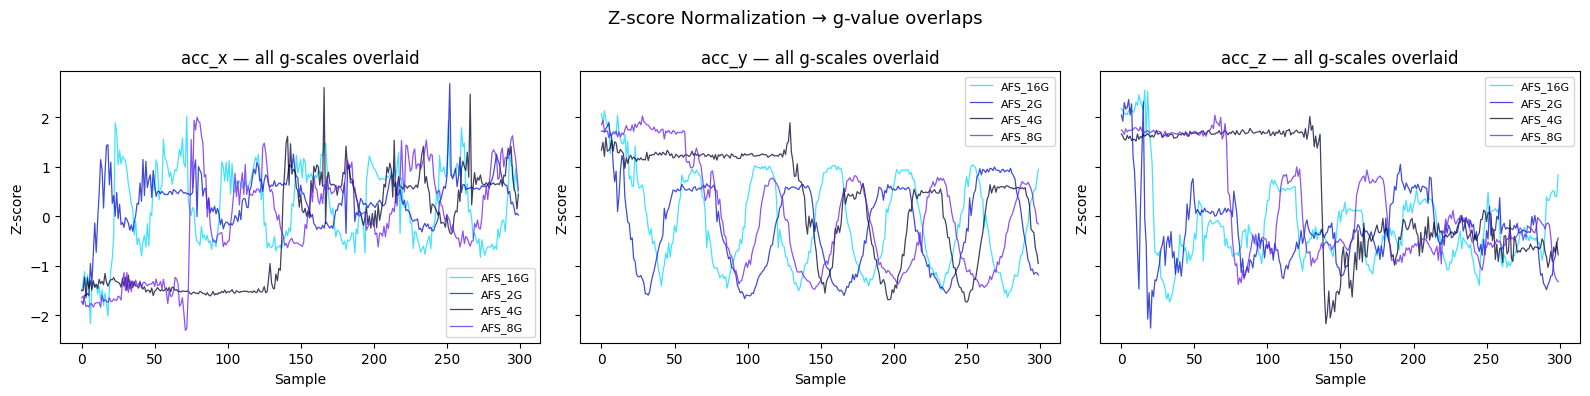

In [16]:
scale_colors = ["#04d9ff", "#010fcc", "#00022e", "#661aee"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for i, gs in enumerate(g_scales):
    subset = df_norm[df_norm["g_scale"] == gs].head(300).reset_index(drop=True)
    for col_idx, ch in enumerate(channels):
        axes[col_idx].plot(subset[ch].values, color=scale_colors[i],
                           linewidth=0.9, alpha=0.75, label=gs)

for col_idx, ch in enumerate(channels):
    axes[col_idx].set_title(f"{ch} — all g-scales overlaid")
    axes[col_idx].set_xlabel("Sample")
    axes[col_idx].set_ylabel("Z-score")
    axes[col_idx].legend(fontsize=8)

plt.suptitle("Z-score Normalization → g-value overlaps", fontsize=13)
plt.tight_layout()
plt.show()

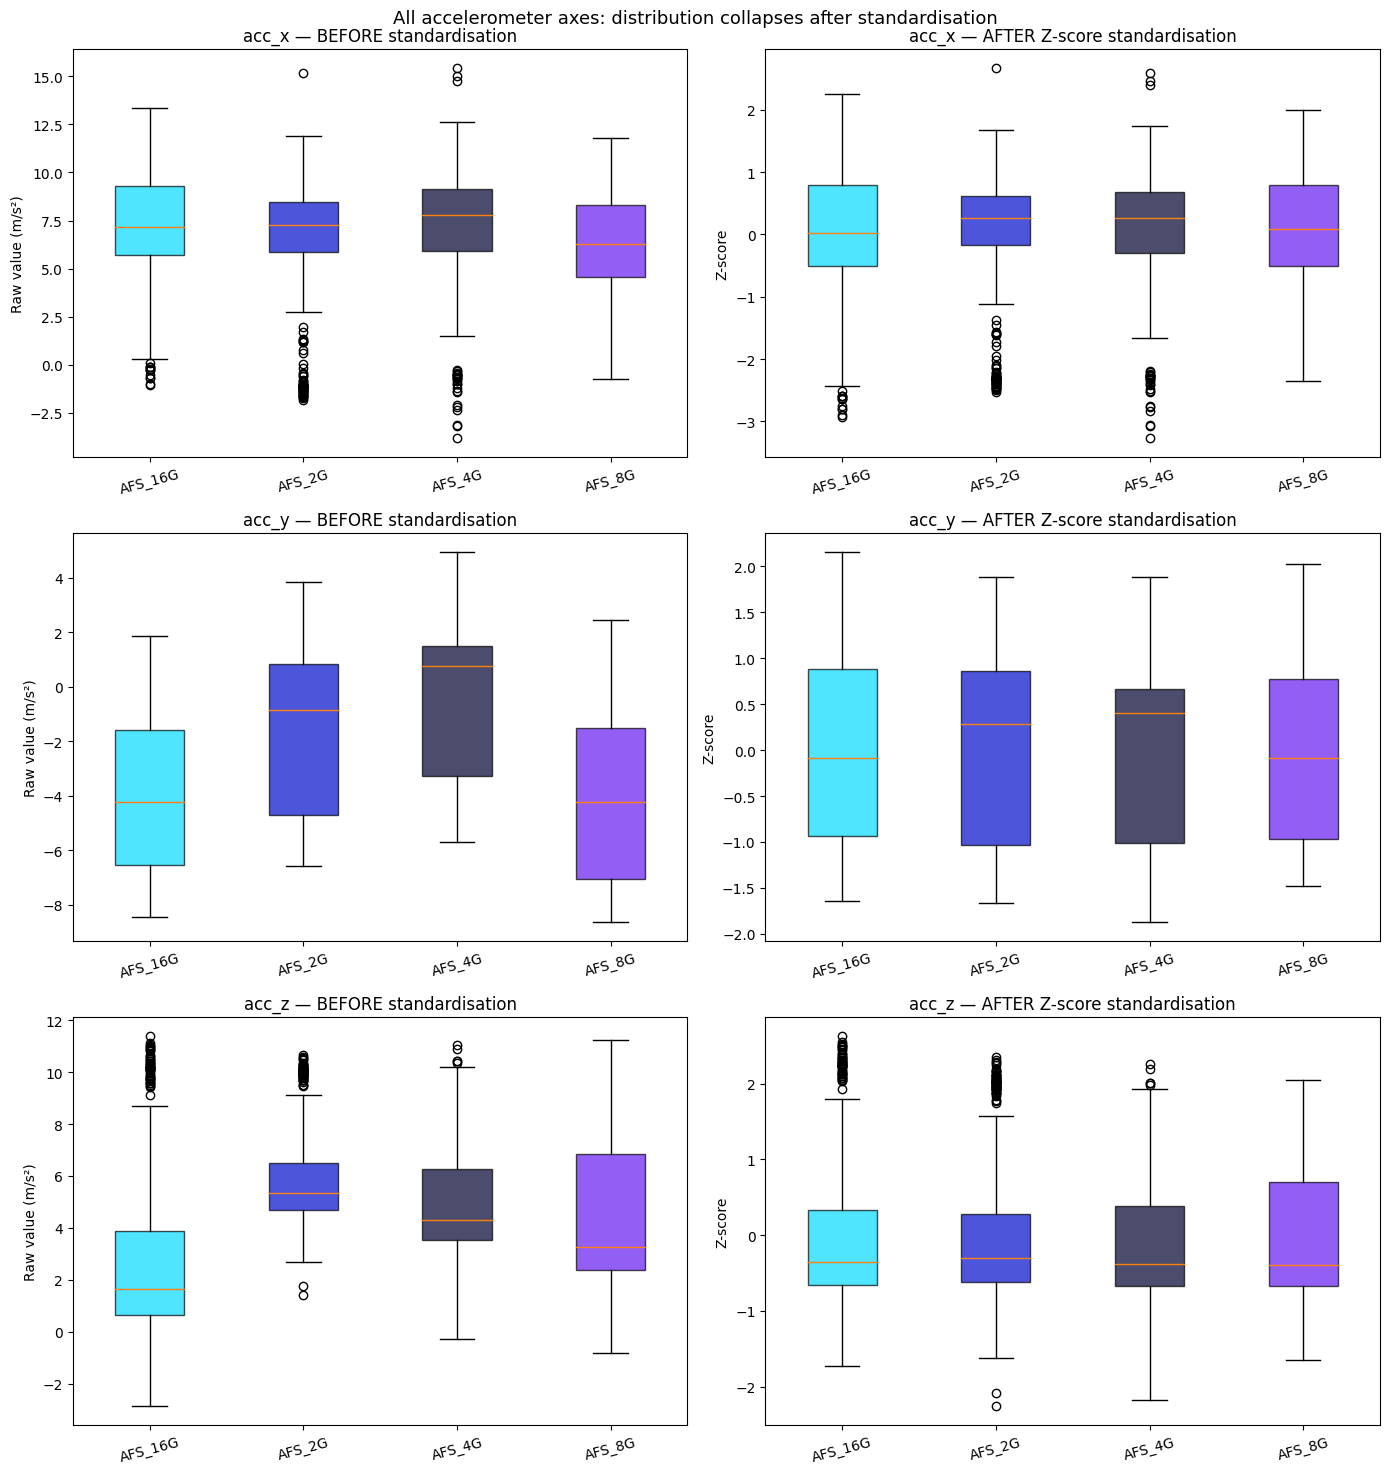

In [17]:
channels_to_plot = ["acc_x", "acc_y", "acc_z"]

fig, axes = plt.subplots(len(channels_to_plot), 2, figsize=(14, 5 * len(channels_to_plot)))

for row, ch in enumerate(channels_to_plot):
    # Before
    data_before = [df_all[df_all["g_scale"]==gs][ch].values for gs in g_scales]
    bp1 = axes[row][0].boxplot(data_before, labels=g_scales, patch_artist=True)
    for patch, color in zip(bp1["boxes"], scale_colors):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    axes[row][0].set_title(f"{ch} — BEFORE standardisation")
    axes[row][0].set_ylabel("Raw value (m/s²)")
    axes[row][0].tick_params(axis="x", rotation=15)

    # After
    data_after = [df_norm[df_norm["g_scale"]==gs][ch].values for gs in g_scales]
    bp2 = axes[row][1].boxplot(data_after, labels=g_scales, patch_artist=True)
    for patch, color in zip(bp2["boxes"], scale_colors):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    axes[row][1].set_title(f"{ch} — AFTER Z-score standardisation")
    axes[row][1].set_ylabel("Z-score")
    axes[row][1].tick_params(axis="x", rotation=15)

plt.suptitle("All accelerometer axes: distribution collapses after standardisation", fontsize=13)
plt.tight_layout()
plt.show()